# 阶段 4：MiniMind 从头预训练

本 Notebook 解释 MiniMind 预训练的数据与参数更新流程，并记录小数据记忆测试、64M 正式训练、固定生成和七任务评估的实际结果。可复用的数据、训练、checkpoint 和评估实现位于 `src/llm_learning/minimind/`。

阅读顺序为：固定两套运行 → 构造 batch 与 loss → 处理 padding mask → gradient accumulation → optimizer step → 区分固定训练集 loss 与 validation loss → checkpoint → 固定生成与七任务评估。

In [1]:
# 导入阶段 4 的固定配置与可复用实现。
import inspect
import json
import math
import statistics
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from IPython.display import Markdown, display
from matplotlib_inline.backend_inline import set_matplotlib_formats
from transformers import AutoTokenizer

from llm_learning.minimind.config import load_pretrain_config
from llm_learning.minimind.data import MiniMindPretrainDataset
from llm_learning.minimind.inspect import load_official_model_module
from llm_learning.minimind.train import (
    cosine_learning_rate, make_grad_scaler, run_training,
    total_optimizer_steps,
)

set_matplotlib_formats('svg')
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
CONFIG_DIR = ROOT / 'docs/stages/04_pretrain/configs'
OVERFIT_CONFIG = load_pretrain_config(CONFIG_DIR / 'overfit256.json')
MINI64_CONFIG = load_pretrain_config(CONFIG_DIR / 'mini64.json')
print('PyTorch:', torch.__version__)
print('CUDA:', torch.cuda.is_available())

PyTorch: 2.9.1
CUDA: True


## 1. 先冻结实验身份

一次训练由模型源码、Tokenizer、数据划分、随机种子和训练配置共同确定。revision 表示固定的源码或数据版本；split 表示 train 与 validation 的划分规则。只记录“64M 模型、seed 42”无法定位同一次运行。

本阶段使用两种互相独立的运行：

- `overfit256`：固定取原始 row ID 0-255，验证训练链路能否记住小数据集。配置把 epoch ceiling 设为 1,000，同时把 optimizer step 上限设为 1,000；达到 loss 不高于 1.0 时提前停止。本次实际在第 30 个 epoch、step 240 停止。
- `mini64`：重新随机初始化官方 64M Dense 模型。seed 42 的随机排列先取 2,048 行作为 validation，其余行作为 train。

`data_lock.json` 在运行前固定数据来源与 revision。运行后生成的 manifest 记录实际读取的数据和划分，用于确认恢复训练时仍使用同一组输入。

训练配置还确定三个会贯穿后文的量：`batch_size` 对应 batch 维度 $B$，`sequence_length` 对应序列维度 $T$，`accumulation_steps` 表示多少个不同 microbatch 的梯度共同形成一次 optimizer step。

In [2]:
# 对比小数据记忆测试与正式 64M 运行的核心配置。
fields = [
    'hidden_size', 'num_hidden_layers', 'num_attention_heads',
    'num_key_value_heads', 'sequence_length', 'batch_size',
    'accumulation_steps', 'effective_batch_size', 'epochs',
    'max_optimizer_steps', 'overfit_loss_target', 'dtype',
]
config_rows = [
    '| field | overfit256 | mini64 |',
    '| --- | ---: | ---: |',
]
for name in fields:
    config_rows.append(
        f'| `{name}` | {getattr(OVERFIT_CONFIG, name) or "-"} | '
        f'{getattr(MINI64_CONFIG, name) or "-"} |'
    )
display(Markdown('\n'.join(config_rows)))

| field | overfit256 | mini64 |
| --- | ---: | ---: |
| `hidden_size` | 256 | 768 |
| `num_hidden_layers` | 4 | 8 |
| `num_attention_heads` | 4 | 8 |
| `num_key_value_heads` | 2 | 4 |
| `sequence_length` | 128 | 340 |
| `batch_size` | 16 | 32 |
| `accumulation_steps` | 2 | 8 |
| `effective_batch_size` | 32 | 256 |
| `epochs` | 1000 | 2 |
| `max_optimizer_steps` | 1000 | - |
| `overfit_loss_target` | 1.0 | - |
| `dtype` | bfloat16 | bfloat16 |

## 2. 一条文本怎样组成 $[B,T]$ batch

Dataset 按以下顺序处理文本。示例中的 token 只用于说明位置，不代表 MiniMind Tokenizer 的实际切分结果。

1. 每条文本独立编码。两条文本分别得到各自的 token 序列，不会先拼接成一条长文本。

```text
文本 A → [我, 爱, 猫]
文本 B → [天气, 很好]
```

2. 在每条 token 序列的两端加入 BOS 与 EOS。

```text
[我, 爱, 猫]
→ [BOS, 我, 爱, 猫, EOS]
```

3. 长度不足 $T$ 时执行 right padding。假设 $T=7$，就在 EOS 后补 PAD。

```text
[BOS, 我, 爱, 猫, EOS]
→ [BOS, 我, 爱, 猫, EOS, PAD, PAD]
```

4. 文本 token 超过 $T-2$ 时，先截断文本 token，再加入 BOS 与 EOS。假设 $T=7$，文本最多保留 5 个 token。

```text
[a, b, c, d, e, f, g]
→ 截断为 [a, b, c, d, e]
→ [BOS, a, b, c, d, e, EOS]
```

处理完成后，单条样本的 shape 为 $[T]$；DataLoader 再把 $B$ 条样本堆叠成一个 $[B,T]$ batch。

- `input_ids` 的 shape 为 $[B,T]$。每个元素是 token ID。
- 模型先映射为 hidden states，shape 为 $[B,T,D]$。
- LM head 输出 logits，shape 为 $[B,T,V]$。
- `labels` 也为 $[B,T]$。PAD 位置写成 `-100`，不参与交叉熵。

模型内部先执行 label shift：位置 $0$ 到 $T-2$ 的 logits 分别预测位置 $1$ 到 $T-1$ 的 labels。PAD label 为 `-100`，cross entropy 会忽略这些位置。模型返回参与训练位置的 mean loss，因此有效 token 数从 `labels[..., 1:] != -100` 统计。

$B$ 表示同时处理的不同序列数量，$T$ 表示每条序列的长度。下一节的 gradient accumulation 会连续读取多个不同的 $[B,T]$ microbatch；每条序列仍然保留完整的 $T$ 个位置。

In [3]:
# 固定随机种子，用真实 MiniMind Tokenizer 和缩小模型检查一次数据流。
SAMPLE_SEED = 2026
SAMPLE_DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(SAMPLE_SEED)
if SAMPLE_DEVICE.type == 'cuda':
    torch.cuda.manual_seed_all(SAMPLE_SEED)

source_dir = ROOT / 'third_party/minimind'
tokenizer = AutoTokenizer.from_pretrained(source_dir / 'model')
records = [
    {'text': '语言模型根据已有 token 预测下一个 token。'},
    {'text': '梯度累积不会增加一次 forward 的 batch size。'},
]
dataset = MiniMindPretrainDataset(records, [0, 1], tokenizer, sequence_length=32)
batch = {
    name: torch.stack([dataset[0][name], dataset[1][name]]).to(SAMPLE_DEVICE)
    for name in ['input_ids', 'labels']
}

official = load_official_model_module(source_dir)
model_config = official.MiniMindConfig(
    hidden_size=256, num_hidden_layers=4, num_attention_heads=4,
    num_key_value_heads=2, vocab_size=len(tokenizer),
    max_position_embeddings=128, dropout=0.0, use_moe=False,
)
model = official.MiniMindForCausalLM(model_config).to(SAMPLE_DEVICE).eval()
with torch.no_grad():
    output = model(batch['input_ids'], labels=batch['labels'], use_cache=False)
parameter = next(model.parameters())
valid_shifted_labels = batch['labels'][..., 1:].ne(-100).sum().item()
print('seed:', SAMPLE_SEED)
print('device:', parameter.device)
print('parameter dtype:', parameter.dtype)
print('input_ids:', tuple(batch['input_ids'].shape))
print('hidden_states:', tuple(output.hidden_states.shape))
print('logits:', tuple(output.logits.shape))
print('logits dtype:', output.logits.dtype)
print('valid shifted labels:', valid_shifted_labels)
print('random model loss:', output.loss.item())
print('uniform baseline log(V):', math.log(len(tokenizer)))

seed: 2026
device: cuda:0
parameter dtype: torch.float32
input_ids: (2, 32)
hidden_states: (2, 32, 256)
logits: (2, 32, 6400)
logits dtype: torch.float32
valid shifted labels: 32
random model loss: 8.86014175415039
uniform baseline log(V): 8.764053269347762


### 这个单元只检查 shape 与 loss 接口

上面的临时示例使用 $B=2$、$T=32$，用于快速检查 Tensor shape，不代表 `overfit256` 或 `mini64` 的训练配置。模型参数保持 FP32，forward 也没有进入 autocast，所以输出 dtype 是 `torch.float32`；正式训练才按配置启用 BF16 autocast。

随机初始化模型的 loss 接近 $\log(V)$，这里只用于确认 loss 数值有限且接口可以工作。它不是训练结果，也不能说明模型已经学到数据。

### 为什么训练 forward 没有传入 padding mask

`MiniMindPretrainDataset` 会返回 padding `attention_mask`，便于检查样本；`run_training` 只把 `input_ids` 与 `labels` 传给模型。本阶段每条样本独立编码并使用 right padding。causal mask 由模型内部处理，用于阻止当前位置看到未来；右侧 PAD 不会影响它左侧的有效 token，PAD labels 又是 `-100`，因此这些位置不会进入 loss。

这个结论只适用于当前的标准 right padding 与 causal LM loss。left padding、序列拼接、bidirectional attention 或其他 loss 需要重新判断。项目测试会比较单独序列与 right-padding batch 的有效位置 logits，防止这一前提被后续改动破坏。

## 3. 为什么沿 $B$ 维度累积梯度再执行 optimizer step

前几个阶段的模型较小，一个 batch 完成 backward 后可以立即执行 optimizer step。阶段 4 的正式配置选择 microbatch size 32 和 `accumulation_steps=8`，使一次参数更新汇总 256 条序列，同时控制单次 forward 的显存。拆分只发生在 $B$ 维度，$T$ 始终保持 340。

```text
前几个阶段
一个 batch → forward → backward → optimizer step

阶段 4
不同 microbatch 1：[32, 340] → forward → backward ┐
不同 microbatch 2：[32, 340] → forward → backward ├→ 累积梯度
...                                                   │
不同 microbatch 8：[32, 340] → forward → backward ┘
→ 汇总 256 条序列的梯度
→ optimizer step
```

每个 microbatch 使用不同的序列。累积期间不执行 optimizer step，所以这些梯度都基于同一组模型参数。每个 microbatch 的 loss 除以 `accumulation_steps` 后再 backward，累积结果近似一次输入 $[256,340]$ 所得的平均梯度。epoch 尾部不足 8 个 microbatch 时，改用实际数量缩放 loss。

gradient accumulation 降低的是峰值显存，代价是多次执行 forward 和 backward。它不会降低单个 $[32,340]$ microbatch 所需的激活显存。

下面直接读取 `run_training` 与 `make_grad_scaler` 的真实代码。输出只保留 group size、backward、更新门槛和 optimizer step 相关行。

In [4]:
# 展示 gradient accumulation、optimizer step 与 GradScaler 配置的真实实现。
def show_source_range(function, start_marker, end_marker):
    lines, first_line = inspect.getsourcelines(function)
    start = next(i for i, line in enumerate(lines) if start_marker in line)
    end = next(i for i, line in enumerate(lines) if end_marker in line)
    for offset in range(start, end + 1):
        print(f'{first_line + offset:4d}: {lines[offset]}', end='')

print('1. group size、forward 与 backward')
show_source_range(
    run_training, 'if microbatches_in_update == 0:',
    'scaler.scale(backward_loss).backward()',
)
print('\n2. 累积门槛')
show_source_range(
    run_training, 'microbatches_in_update += 1',
    'continue',
)
print('\n3. optimizer step')
show_source_range(
    run_training, 'scaler.unscale_(optimizer)',
    'optimizer.zero_grad',
)
print('\n4. GradScaler 启用条件')
print(inspect.getsource(make_grad_scaler))

1. group size、forward 与 backward
 357:             if microbatches_in_update == 0:
 358:                 group_size = min(
 359:                     config.accumulation_steps,
 360:                     total_batches - absolute_batch_index,
 361:                 )
 362:                 group_start = time.perf_counter()
 363: 
 364:             input_ids = batch["input_ids"].to(device, non_blocking=True)
 365:             labels = batch["labels"].to(device, non_blocking=True)
 366:             with autocast_context(device, config.dtype):
 367:                 output = model(input_ids, labels=labels, use_cache=False)
 368:                 loss = output.loss
 369:                 if loss is None:
 370:                     raise RuntimeError("training loss was not produced")
 371:                 backward_loss = loss / group_size
 372:             scaler.scale(backward_loss).backward()

2. 累积门槛
 376:             microbatches_in_update += 1
 377:             training_state["next_batch"] = ab

### 真实代码与流程怎样对应

1. `group_size` 通常等于 `accumulation_steps`；epoch 尾部不足一个完整 accumulation window 时，它等于剩余 microbatch 数。
2. `backward_loss = loss / group_size` 缩放当前 loss。调用 `backward()` 后，PyTorch 把 gradient 累加到参数的 `.grad`。
3. `microbatches_in_update != group_size` 时执行 `continue`，所以当前 microbatch 后不会运行 optimizer step。
4. 达到 `group_size` 后，代码才执行 `unscale_()`、clipping、设置 learning rate、`scaler.step()` 和 `zero_grad()`。

### BF16 与 disabled GradScaler

模型参数、`.grad` 和 AdamW 状态保持 FP32。autocast 只让适合的 forward 算子使用 BF16，以减少 activation memory，并降低这些算子的计算与 memory bandwidth 开销。

`make_grad_scaler` 只在 CUDA FP16 下启用 GradScaler。本阶段使用 BF16，因此 scaler 对象处于 disabled 状态。训练循环仍保留统一调用：`scale()` 返回未缩放的 loss，`unscale_()` 与 `update()` 不改变状态，`step()` 直接调用 `optimizer.step()`。

```text
BF16 autocast forward
→ backward
→ .grad（FP32）
→ unscale_()（disabled scaler，不改变 gradient）
→ gradient clipping
→ 设置 learning rate
→ AdamW step
→ zero_grad()
```

### gradient clipping

把所有参数的 gradient 展平并视为一个向量 $\mathbf{g}$。令配置阈值 $c=1.0$，`clip_grad_norm_()` 的处理过程为：

$$
r=\lVert \mathbf{g} \rVert_2,\qquad
s=\min\left(1,\frac{c}{r+\varepsilon}\right),\qquad
\mathbf{g}'=s\mathbf{g}.
$$

当 $s=1$ 时 gradient 保持不变；当 $s<1$ 时，所有 gradient 按同一比例缩小。PyTorch 使用 $\varepsilon=10^{-6}$ 防止除零。该函数返回 clipping 前的 norm，所以日志中的 `gradient_norm` 可以大于 1.0。clipping 不对 hidden states 做 normalization。

### learning rate 为什么按 optimizer step 变化

参数只在 optimizer step 时更新，因此 cosine learning-rate schedule 也按 optimizer step 推进。下一个单元使用数据 manifest 中的真实 row count 计算 `mini64` 的计划更新次数。


In [5]:
# 使用实际数据 row count 计算正式运行的 optimizer steps。
manifest_path = ROOT / 'outputs/minimind/stage4/overfit256/data_manifest.json'
data_manifest = json.loads(manifest_path.read_text(encoding='utf-8'))
total_rows = data_manifest['split']['row_count']
mini64_train_rows = total_rows - MINI64_CONFIG.validation_rows
steps = total_optimizer_steps(MINI64_CONFIG, train_rows=mini64_train_rows)
positions = [0, steps // 2, steps - 1]
print('total data rows:', total_rows)
print('mini64 train rows:', mini64_train_rows)
print('effective batch size:', MINI64_CONFIG.effective_batch_size)
print('planned optimizer steps:', steps)
print(f"{'optimizer step':>14s} {'learning rate':>14s}")
for step in positions:
    lr = cosine_learning_rate(
        step, steps, MINI64_CONFIG.learning_rate, MINI64_CONFIG.minimum_lr_ratio
    )
    print(f'{step:14d} {lr:14.8f}')

total data rows: 1270238
mini64 train rows: 1268190
effective batch size: 256
planned optimizer steps: 9908
optimizer step  learning rate
             0     0.00050000
          4954     0.00027496
          9907     0.00005000


## 4. 区分固定训练集 loss 与 validation loss

训练过程记录 train loss、learning rate、gradient norm、有效 token 数、累计训练 token、tokens/s 和 peak allocated GPU memory。loss 按有效 token 数加权汇总，避免长短样本不同的 batch 被等权平均。

`overfit256` 是 profile 名称。它的训练和 evaluation 使用同一组 row ID 0-255；evaluation 只是在 `model.eval()` 下重新计算完整训练集的 mean loss，不属于 validation 或 test。下表因此展示固定训练集 loss，用于检查模型能否记住小数据。

`mini64` 使用独立 validation。周期评估固定读取 validation 的前 256 条，用于观察训练趋势；最终评估读取完整 2,048 条，用于报告正式结果。两者的样本范围不同，不能当成同一条曲线上的两个等价点。评估同时使用 `model.eval()` 与 `torch.no_grad()`；前者关闭 dropout 等训练行为，后者停止构建 autograd graph。

perplexity 是对应 mean loss 的指数变换，表达同一组 token 上的预测难度，不是独立能力指标。

### 小数据记忆测试

| step | fixed-set loss | perplexity | learning rate | gradient norm |
| ---: | ---: | ---: | ---: | ---: |
| 0 | 8.8221 | 6782.357 | - | - |
| 20 | 7.1908 | 1327.118 | 5.00e-04 | 0.599 |
| 40 | 6.7334 | 839.991 | 4.98e-04 | 0.890 |
| 60 | 6.0408 | 420.248 | 4.96e-04 | 1.584 |
| 80 | 5.2439 | 189.398 | 4.93e-04 | 1.744 |
| 100 | 4.4696 | 87.319 | 4.89e-04 | 2.198 |
| 120 | 3.7331 | 41.808 | 4.84e-04 | 2.088 |
| 140 | 3.0432 | 20.972 | 4.79e-04 | 2.219 |
| 160 | 2.4397 | 11.470 | 4.72e-04 | 2.543 |
| 180 | 1.9156 | 6.791 | 4.65e-04 | 1.844 |
| 200 | 1.4673 | 4.337 | 4.57e-04 | 2.075 |
| 220 | 1.0938 | 2.985 | 4.49e-04 | 1.830 |
| 240 | 0.8178 | 2.266 | 4.39e-04 | 2.001 |

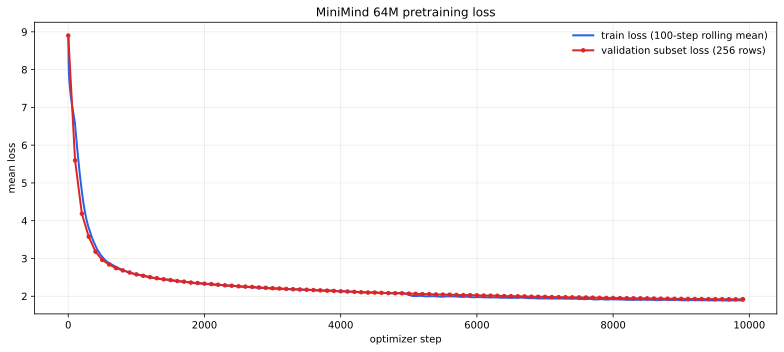

### 正式训练的 validation

| step | evaluation set | loss | perplexity | valid tokens |
| ---: | --- | ---: | ---: | ---: |
| 0 | fixed 256-row subset | 8.9022 | 7348.482 | 53,399 |
| 100 | fixed 256-row subset | 5.5962 | 269.397 | 53,399 |
| 1000 | fixed 256-row subset | 2.5784 | 13.176 | 53,399 |
| 2500 | fixed 256-row subset | 2.2632 | 9.614 | 53,399 |
| 5000 | fixed 256-row subset | 2.0702 | 7.927 | 53,399 |
| 7500 | fixed 256-row subset | 1.9686 | 7.160 | 53,399 |
| 9908 | fixed 256-row subset | 1.9193 | 6.816 | 53,399 |
| 9908 | full 2,048-row validation | 1.9292 | 6.884 | 428,836 |

### 第 1 个与第 2 个 epoch 的对比

| checkpoint | optimizer step | trained tokens | validation loss | perplexity |
| --- | ---: | ---: | ---: | ---: |
| 第 1 个 epoch 结束 | 4,954 | 264,470,476 | 2.0737 | 7.955 |
| 第 2 个 epoch 结束 | 9,908 | 528,940,952 | 1.9193 | 6.816 |
| 第 2 个 epoch 的相对变化 | - | +264,470,476 | -7.4% | - |

### 两项训练的完成状态

| profile | status | optimizer steps | trained tokens |
| --- | --- | ---: | ---: |
| overfit256 | 已完成 | 240 | 913,320 |
| mini64 | 已完成 | 9,908 | 528,940,952 |

In [6]:
# 先展示固定 256 条数据上的记忆测试。
overfit_path = ROOT / 'outputs/minimind/stage4/overfit256/metrics.jsonl'
overfit_metrics = [
    json.loads(line)
    for line in overfit_path.read_text(encoding='utf-8').splitlines()
]
overfit_train = {
    row['optimizer_step']: row
    for row in overfit_metrics if row['kind'] == 'train'
}
overfit_rows = [
    '| step | fixed-set loss | perplexity | learning rate | gradient norm |',
    '| ---: | ---: | ---: | ---: | ---: |',
]
for row in overfit_metrics:
    if row['kind'] != 'eval' or row['scope'] != 'train':
        continue
    train_row = overfit_train.get(row['optimizer_step'])
    lr = '-' if train_row is None else f"{train_row['learning_rate']:.2e}"
    grad = '-' if train_row is None else f"{train_row['gradient_norm']:.3f}"
    overfit_rows.append(
        f"| {row['optimizer_step']} | {row['loss']:.4f} | "
        f"{row['perplexity']:.3f} | {lr} | {grad} |"
    )
display(Markdown('### 小数据记忆测试\n\n' + '\n'.join(overfit_rows)))

# 再展示正式训练的 loss 曲线与关键 validation 节点。
mini64_path = ROOT / 'outputs/minimind/stage4/mini64/metrics.jsonl'
mini64_metrics = [
    json.loads(line)
    for line in mini64_path.read_text(encoding='utf-8').splitlines()
]
mini64_train = [row for row in mini64_metrics if row['kind'] == 'train']
periodic_eval = [
    row for row in mini64_metrics
    if row['kind'] == 'eval' and row['scope'] == 'validation_subset'
]
final_eval = next(
    row for row in reversed(mini64_metrics)
    if row['kind'] == 'eval' and row['scope'] == 'validation_full'
)
window = 100
rolling_loss = [
    sum(item['loss'] for item in mini64_train[max(0, i-window+1):i+1])
    / min(window, i + 1)
    for i in range(len(mini64_train))
]
figure, axis = plt.subplots(figsize=(11, 5), dpi=140)
axis.plot(
    [row['optimizer_step'] for row in mini64_train], rolling_loss,
    color='#2563eb', linewidth=2.0,
    label='train loss (100-step rolling mean)',
)
axis.plot(
    [row['optimizer_step'] for row in periodic_eval],
    [row['loss'] for row in periodic_eval],
    color='#dc2626', linewidth=2.0, marker='o', markersize=3.5,
    label='validation subset loss (256 rows)',
)
axis.set_xlabel('optimizer step')
axis.set_ylabel('mean loss')
axis.set_title('MiniMind 64M pretraining loss')
axis.grid(alpha=0.25, linewidth=0.8)
axis.legend(frameon=False)
figure.tight_layout()
plt.show()

selected_steps = {0, 100, 1000, 2500, 5000, 7500, 9908}
validation_rows = [
    '| step | evaluation set | loss | perplexity | valid tokens |',
    '| ---: | --- | ---: | ---: | ---: |',
]
for row in periodic_eval:
    if row['optimizer_step'] in selected_steps:
        validation_rows.append(
            f"| {row['optimizer_step']} | fixed 256-row subset | "
            f"{row['loss']:.4f} | {row['perplexity']:.3f} | "
            f"{row['tokens']:,} |"
        )
validation_rows.append(
    f"| {final_eval['optimizer_step']} | full 2,048-row validation | "
    f"{final_eval['loss']:.4f} | {final_eval['perplexity']:.3f} | "
    f"{final_eval['tokens']:,} |"
)
display(Markdown('### 正式训练的 validation\n\n' + '\n'.join(validation_rows)))

# 使用同一固定 subset，比较第 1 个和第 2 个 epoch 结束时的 checkpoint。
epoch1_eval = json.loads(
    (ROOT / 'outputs/minimind/stage4/mini64/epoch1_evaluation.json').read_text(
        encoding='utf-8'
    )
)
epoch2_eval = next(
    row for row in periodic_eval if row['optimizer_step'] == 9908
)
epoch_comparison_rows = [
    '| checkpoint | optimizer step | trained tokens | validation loss | perplexity |',
    '| --- | ---: | ---: | ---: | ---: |',
    f"| 第 1 个 epoch 结束 | {epoch1_eval['optimizer_step']:,} | "
    f"{epoch1_eval['trained_tokens']:,} | {epoch1_eval['loss']:.4f} | "
    f"{epoch1_eval['perplexity']:.3f} |",
    f"| 第 2 个 epoch 结束 | {epoch2_eval['optimizer_step']:,} | "
    f"{mini64_train[-1]['trained_tokens']:,} | {epoch2_eval['loss']:.4f} | "
    f"{epoch2_eval['perplexity']:.3f} |",
]
loss_reduction = (epoch1_eval['loss'] - epoch2_eval['loss']) / epoch1_eval['loss']
epoch_comparison_rows.append(
    f'| 第 2 个 epoch 的相对变化 | - | +{mini64_train[-1]["trained_tokens"] - epoch1_eval["trained_tokens"]:,} | '
    f'-{loss_reduction:.1%} | - |'
)
display(Markdown(
    '### 第 1 个与第 2 个 epoch 的对比\n\n'
    + '\n'.join(epoch_comparison_rows)
))

status_rows = [
    '| profile | status | optimizer steps | trained tokens |',
    '| --- | --- | ---: | ---: |',
]
for profile in ['overfit256', 'mini64']:
    summary_path = ROOT / f'outputs/minimind/stage4/{profile}/summary.json'
    summary = json.loads(summary_path.read_text(encoding='utf-8'))
    status_rows.append(
        f"| {profile} | 已完成 | {summary['completed_optimizer_steps']:,} | "
        f"{summary['trained_tokens']:,} |"
    )
display(Markdown('### 两项训练的完成状态\n\n' + '\n'.join(status_rows)))

### 小数据记忆测试结果

在固定 MiniMind revision、官方 Tokenizer、原始 row ID 0-255、seed 42 和 `overfit256` 配置下，固定数据 loss 从 8.8221 持续降至 0.8178，并在第 240 个 optimizer step 达到 loss 不高于 1.0 的停止条件。最终 perplexity 为 2.2655，共处理 913,320 个有效训练 token。上表同时列出对应 optimizer step 的 learning rate 和 clipping 前 gradient norm，便于对照训练状态。

这项结果支持当前数据、forward、backward、gradient accumulation、optimizer 和评估链路能够拟合固定小数据。该结果不提供未见文本上的泛化证据。

### 64M 正式训练结果

正式运行完成 2 epochs 和 9,908 个 optimizer steps，共处理 528,940,952 个有效训练 token。周期 validation subset loss 从 8.9022 总体下降到 1.9193；完整 2,048 条 validation 的最终 loss 为 1.9292，perplexity 为 6.8837。两种 validation 结果接近，说明固定 256 条子集在本次运行中能够反映整体水平。

train loss 的单步值会随 batch 内容波动，因此图中使用 100-step rolling mean 观察趋势。train 与 validation 的总体趋势都向下，训练末段 validation 已接近平缓。本次 2-epoch 运行没有出现 train 继续明显下降而 validation 持续上升的证据。这个结论只适用于当前 split、训练长度和评估口径。

### 第一次长训练的观察

这是本项目第一次持续数小时的正式训练。运行前担心一次遍历训练不足，因此把训练长度设为 2 epochs。第 1 个 epoch 已处理 264,470,476 个有效 token，固定 validation subset loss 为 2.0737；第 2 个 epoch 再处理 264,470,476 个 token 后，loss 降到 1.9193，相对下降约 7.4%，perplexity 从 7.95 降到 6.82。第二个 epoch 仍有改善，但边际收益明显小于第一个 epoch。

单个 optimizer step 的 train loss 由当前 batch 的文本内容、长度和预测难度共同影响，因此会正常地上下波动，不要求单调递减。判断参数是否仍在拟合训练数据，应观察 train loss 的 rolling mean；判断模型在同分布未见数据上的泛化能力是否继续改善，应以固定口径的 validation loss 为主要依据。两者回答的问题不同，不能只用某一个 batch 的 train loss 作结论。

当前曲线也不是明显的 grokking。典型 grokking 指模型先把训练集拟合到接近完全正确，validation 表现长期停留在较差水平，随后才突然改善；该现象最初主要在小型 algorithmic datasets 上研究。普通自然语言 LLM pretraining 不应预设会出现这种突变。本次 train 与 validation 从早期开始同步下降，后期逐渐变平，属于常规的渐进改善。

生成结果也呈现相同现象。step 4,954 已经能够围绕 prompt 组织完整中文句子；step 9,908 的结构更稳定，但重复、未完成列表和事实错误仍然存在，没有形成同等幅度的质量跃升。当前只对最终 checkpoint 运行了七任务评估，因此不能据此判断第二个 epoch 对七任务分数的影响。

这次实验带来的训练判断是：不应把 train loss 尽可能降到最低当作唯一目标。更合理的停止依据是 validation 趋势、目标任务表现、生成观察和额外计算成本。对当前配置而言，第二个 epoch 提供了继续改善但收益变小的证据，没有支持再盲目增加 epoch。step 4,954 属于预先按 2 epochs 计算的 cosine learning-rate schedule；它不等价于从一开始就配置 1 epoch 的独立训练。

## 5. checkpoint 为什么只能在 optimizer step 后保存

若在 gradient accumulation 中途保存，却没有保存已经累积的 `.grad`，恢复后会少掉部分 gradient。阶段 4 只在完整 optimizer step 后保存，并拒绝 `microbatches_in_update != 0` 的状态。

完整 checkpoint 包含模型、optimizer、GradScaler、训练位置、配置、Tokenizer 身份、数据 manifest、指标历史和随机数状态。

恢复时先校验训练配置、Tokenizer、原始数据 hash 与 split hash，再加载状态。Dataset fingerprint 受 `datasets` 版本影响，只记录读取环境，不作为跨版本恢复条件。模型权重快照只用于生成和格式转换，不能代替训练恢复 checkpoint。正式训练的 `latest.pt` 保存了 step 9,908 的完整状态；下一个单元读取已经完成实际重载检查的 `overfit256` checkpoint 元数据，不执行训练。

In [7]:
# 读取 checkpoint 元数据，确认保存边界与恢复位置。
checkpoint_path = ROOT / 'checkpoints/minimind/stage4/overfit256/latest.pt'
checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
training_state = checkpoint['training_state']
state_rows = ['| field | value |', '| --- | ---: |']
for name in [
    'epoch', 'next_batch', 'optimizer_step', 'trained_tokens',
    'microbatches_in_update', 'stop_reason',
]:
    state_rows.append(f'| `{name}` | {training_state[name]} |')
display(Markdown('**Checkpoint sections**: ' + ', '.join(checkpoint.keys())))
display(Markdown('\n'.join(state_rows)))

**Checkpoint sections**: model, optimizer, scaler, training_state, config, tokenizer, data_manifest, history, rng_state

| field | value |
| --- | ---: |
| `epoch` | 30 |
| `next_batch` | 0 |
| `optimizer_step` | 240 |
| `trained_tokens` | 913320 |
| `microbatches_in_update` | 0 |
| `stop_reason` | overfit_loss_target |

## 6. 固定生成与客观评估

正式 64M checkpoint 产生后，固定三条 prompts 分别运行 greedy decoding 与 sampling。greedy 每步选择最高分 token，此时 temperature、top-k、top-p 和 sampling seed 不参与决策；sampling 才会根据这些参数处理分布并抽样。sampling 使用独立 `torch.Generator`，不会消耗训练随机数状态。

checkpoint 对比必须保持 prompts、解码方式、最大生成长度、EOS 和 sampling seed 相同。否则输出变化可能来自随机采样，不能归因于训练。

客观基线先调用 MiniMind 官方转换脚本导出 Qwen3 兼容 Transformers checkpoint，并检查固定输入 logits。转换只改变 checkpoint 格式，不应改变同一输入上的 logits。

准备脚本从 0.4.12 的上游 task YAML 生成本地副本，注入冻结的 Dataset revision 与 `trust_remote_code: true`，再记录目录 hash。授权只用于运行完整 commit 已固定的旧式 Dataset scripts。`lm-evaluation-harness` 的 `hf` backend 从本地路径运行七项现成任务。本项目不重新实现任务 prompt、标签或评分器。七任务使用 accuracy 类指标时，分数越高表示答对的样本比例越高；不同任务的数据与难度不同，不把七个分数直接平均成新的能力指标。

实际生成显示，step 0 主要输出无意义片段和重复 token；step 4,954 已能围绕问题组织中文回答；step 9,908 的回答结构更稳定。中间与最终 checkpoint 仍会重复句子、生成未完成列表或给出错误事实。三条 prompts 只用于观察输出变化，不用于证明模型具备可靠问答能力。

在同一个最终 checkpoint 上，greedy decoding 与 sampling 的措辞和内容不同。greedy 更容易重复高概率片段；sampling 增加了变化，也可能引入新的事实错误。固定 sampling seed 只让这次抽样可以复现，不表示 sampling 输出普遍优于 greedy。

七任务实测大致处在对应选择题的随机选择水平附近：四选一约为 0.25，PIQA 二选一约为 0.50，SocialIQA 三选一约为 0.33。当前结果没有显示出稳定的 zero-shot multiple-choice 能力。这与 64M base model、有限训练 token 和未做 instruction tuning 的实验条件一致。

In [8]:
# 读取固定配置与实际生成记录。
generation_config = json.loads(
    (CONFIG_DIR / 'generation.json').read_text(encoding='utf-8')
)
generation_result = json.loads(
    (ROOT / 'outputs/minimind/stage4/mini64/generation.json').read_text(
        encoding='utf-8'
    )
)
config_rows = [
    '| mode | do_sample | temperature | top-k | top-p | max new tokens | seed |',
    '| --- | --- | ---: | ---: | ---: | ---: | ---: |',
]
for mode in ['greedy', 'sampling']:
    values = generation_config[mode]
    config_rows.append(
        f"| {mode} | {values['do_sample']} | {values['temperature']} | "
        f"{values['top_k']} | {values['top_p']} | "
        f"{values['max_new_tokens']} | {values['seed']} |"
    )
display(Markdown('### 固定 generation config\n\n' + '\n'.join(config_rows)))

summary_rows = [
    '| checkpoint | mode | generated-token range | median tokens/s |',
    '| --- | --- | ---: | ---: |',
]
for checkpoint_result in generation_result['checkpoints']:
    checkpoint_name = Path(checkpoint_result['checkpoint']).stem
    for mode, items in checkpoint_result['modes'].items():
        lengths = [item['generated_tokens'] for item in items]
        speeds = [item['tokens_per_second'] for item in items]
        summary_rows.append(
            f"| {checkpoint_name} | {mode} | {min(lengths)}-{max(lengths)} | "
            f"{statistics.median(speeds):.1f} |"
        )
display(Markdown('### 三个 checkpoint 的生成记录\n\n' + '\n'.join(summary_rows)))

# 用同一条 prompt 展示权重变化；再增加最终 checkpoint 的 sampling 对照。
prompt = '为什么天空是蓝色的'
selected = []
for checkpoint_result in generation_result['checkpoints']:
    greedy_item = next(
        item for item in checkpoint_result['modes']['greedy']
        if item['prompt'] == prompt
    )
    selected.append((Path(checkpoint_result['checkpoint']).stem, 'greedy', greedy_item))
final_sampling = next(
    item for item in generation_result['checkpoints'][-1]['modes']['sampling']
    if item['prompt'] == prompt
)
selected.append(('weights_step_9908', 'sampling', final_sampling))
for checkpoint_name, mode, item in selected:
    display(Markdown(
        f"**{checkpoint_name} / {mode}**\n\n> {item['text']}"
    ))

# 读取 lm-evaluation-harness 的七任务结果。
lm_eval_config = json.loads(
    (CONFIG_DIR / 'lm_eval.json').read_text(encoding='utf-8')
)
result_files = sorted(
    (ROOT / 'outputs/minimind/stage4/lm_eval_results').glob('**/results_*.json')
)
lm_eval_result = json.loads(result_files[-1].read_text(encoding='utf-8'))
primary_metrics = {
    'ceval-valid': 'acc,none',
    'cmmlu': 'acc,none',
    'arc_easy': 'acc_norm,none',
    'piqa': 'acc_norm,none',
    'openbookqa': 'acc_norm,none',
    'hellaswag': 'acc_norm,none',
    'social_iqa': 'acc,none',
}
score_rows = [
    '| task | primary metric | samples | score | standard error |',
    '| --- | --- | ---: | ---: | ---: |',
]
for task_name, metric_name in primary_metrics.items():
    task_result = lm_eval_result.get('groups', {}).get(task_name)
    if task_result is None:
        task_result = lm_eval_result['results'][task_name]
    stderr_name = metric_name.replace(',none', '_stderr,none')
    score_rows.append(
        f"| {task_name} | {metric_name.split(',')[0]} | "
        f"{task_result['sample_len']:,} | "
        f"{task_result[metric_name]:.4f} | {task_result[stderr_name]:.4f} |"
    )
display(Markdown(
    f"### 七任务结果\n\n`lm-evaluation-harness` "
    f"{lm_eval_config['lm_eval_version']}\n\n" + '\n'.join(score_rows)
))

### 固定 generation config

| mode | do_sample | temperature | top-k | top-p | max new tokens | seed |
| --- | --- | ---: | ---: | ---: | ---: | ---: |
| greedy | False | 1.0 | 0 | 1.0 | 128 | 2026 |
| sampling | True | 0.85 | 50 | 0.95 | 128 | 2026 |

### 三个 checkpoint 的生成记录

| checkpoint | mode | generated-token range | median tokens/s |
| --- | --- | ---: | ---: |
| weights_step_0 | greedy | 128-128 | 150.2 |
| weights_step_0 | sampling | 128-128 | 136.1 |
| weights_step_4954 | greedy | 128-128 | 151.4 |
| weights_step_4954 | sampling | 114-128 | 141.3 |
| weights_step_9908 | greedy | 108-128 | 143.7 |
| weights_step_9908 | sampling | 128-128 | 128.1 |

**weights_step_0 / greedy**

> ge直接集合南 dr dr dr dr dr dr dr dr dr dr dr dr需要需要需要需要需要需要需要需要需要需要需要需要antsantsantsantsantsantsantsantsantsantsantsantsantsantsantsantsantsantsantsantsantsantsantsantsantsantsantsantsantsantsantsants润

**weights_step_4954 / greedy**

> ？天空之所以呈现蓝色，是因为太阳光线在穿过大气层时，会被散射，使得蓝光波长较短，更容易被散射。那为什么天空是蓝色的？天空之所以呈现蓝色，是因为太阳光线在穿过大气层时，会被散射，使得蓝光波长较短，更容易被散射。那为什么天空是蓝色的？天空之所以呈现蓝色，是因为太阳光线在穿过大气层时，会被散射

**weights_step_9908 / greedy**

> ？天空之所以呈现蓝色，是因为大气层中的气体分子会散射太阳光中的蓝色光，而蓝色光的波长较短，更容易被散射。那么为什么天空是蓝色的呢？天空之所以呈现蓝色，是因为太阳光中的蓝色光波长较短，更容易被散射。而蓝色光波长较长，更容易被散射，所以天空呈现蓝色。

**weights_step_9908 / sampling**

> ？天空看起来是蓝色的，是因为太阳的光线需要穿过大气层的散射。当太阳光线穿过大气层时，它会散射掉更多的蓝色光线。蓝色光线是由不同波长的光组成的，因此它们穿过大气层的散射会使更多的蓝色光线散射在我们的眼睛中，而蓝色光线则通过大气层散射，使我们能够看到天空。此外，天空中的红、橙、黄、绿等颜色也可以被分散，使天

### 七任务结果

`lm-evaluation-harness` 0.4.12

| task | primary metric | samples | score | standard error |
| --- | --- | ---: | ---: | ---: |
| ceval-valid | acc | 1,346 | 0.2377 | 0.0117 |
| cmmlu | acc | 11,582 | 0.2506 | 0.0040 |
| arc_easy | acc_norm | 2,376 | 0.2908 | 0.0093 |
| piqa | acc_norm | 1,838 | 0.5087 | 0.0117 |
| openbookqa | acc_norm | 500 | 0.2740 | 0.0200 |
| hellaswag | acc_norm | 10,042 | 0.2852 | 0.0045 |
| social_iqa | acc | 1,954 | 0.3480 | 0.0108 |

## 7. 阶段验收时回答的问题

**模型训练的 token 总数是什么？**

正式 64M 运行累计训练 528,940,952 个有效 token。这个值是每次 optimizer step 中 `labels[..., 1:] != -100` 的数量之和；PAD 和序列第一个 label 不计入。

**effective batch size 是多少？**

一个 microbatch 包含 32 条序列，连续累积 8 个 microbatches 后执行一次 optimizer step，因此常规 step 的 effective batch size 为 $32\times8=256$ 条序列。epoch 尾部不足 8 个 microbatches 时按实际数量完成最后一次更新。

**train loss 与 validation loss 应怎样判断？**

小数据记忆测试的固定训练集 loss 从 8.8221 降到 0.8178。正式运行的 train loss rolling mean 与周期 validation loss 总体同时下降；完整 validation 最终 loss 为 1.9292。训练末段 validation 接近平缓，没有出现持续反向上升。

**显存主要花在哪里？**

主要包括模型参数、gradient、AdamW 的一阶与二阶状态，以及 forward 为 backward 保留的 activations。本次实测 peak allocated GPU memory 为 6.13 GiB。模型结构固定后，增加 microbatch size 或 sequence length 会直接增加 activations。

**generation config 为什么必须固定？**

greedy decoding 每步选择最高分 token；sampling 会受到 temperature、top-k、top-p 和 random seed 影响。比较 checkpoint 时固定 prompts、decoding 参数和 sampling seed，才能把输出差异主要归因于模型权重变化。

**checkpoint 恢复正确的最低证据是什么？**

checkpoint 保存模型、optimizer、训练位置、配置、数据身份与随机数状态。专项测试比较 uninterrupted 训练与 save/load 后的下一次 AdamW update，参数完全相同；`overfit256/latest.pt` 的实际重载也保持 step 240、累计 token 和停止原因不变。两项证据共同支持当前恢复链路正确。

## 8. 阶段 5 前瞻：从 Pretrain 到 SFT

阶段 4 的 labels 覆盖文本中全部有效的 next-token 位置。阶段 5 会把一条对话渲染成连续 token 序列，但只让 assistant response 对应的 labels 参与 loss；system 与 user token 的 labels 设为 `-100`。

下一阶段先打印一个样本的 token、token ID、role、label 和是否计算 loss，确认 response mask、EOS 与截断位置。完成单样本检查后再启动完整训练。模型 forward、梯度累积、checkpoint 和固定评估口径将直接继承本阶段。